# Computer Vision - P1

### *Carefully read the following instructions before start coding.*

### **Prerequisite**

- Before starting P1, you must **complete the 'p1_tutorial'.** The tutorial introduces the key concepts and steps needed to complete the practice successfully. Completing it first will help you understand the requirements and avoid common mistakes.


==============================================================================================

## **P1: Basics on Image Processing and Manipulation**
==============================================================================================

### The main topics are:

1. Image loading, saving and creation

2. Color manipulation

To complete this exercise, we will work with the following concepts: **image creation**, **data types**, and **image manipulation**.

==============================================================================================
### Packages loading

First we need to import the required Python packages for basic image manipulation.

Run the following code:

In [2]:
import numpy as np # useful for manipulating matrices
from skimage import io # useful for image loading and saving
from matplotlib import pyplot as plt # useful for plotting images on iPython or Jupyter Notebooks

Note that commands starting with the percentage sign (`%`) are special internal commands to ipython (as opposed to Python code to be run). In the case below, we set the matplotlib environment to display images results inline (i.e. the images will be shown **inside the
notebook**):

In [3]:
%matplotlib inline

==============================================================================================

### **1.1 Image creation**

Remember that [Numpy](https://docs.scipy.org/doc/numpy-1.13.0/reference/) allows us to define images of different kinds treating them as matrices.

The most common examples are:

* Binary: with values of 0 or 1, interpreted as black or white, respectively.
* Grayscale: with possible data types uint8, uint16, double, whose pixel values define their intensity.
* RGB Image: color images consisting of 3 matrices (usually called 'channels'), which contain intensity values for each color separately R (red), G (green) and B (blue).


**a) Create and display a 100 × 100 grayscale image represented as a 2D array.**
 - Each element of the array must be an 8-bit unsigned integer (`uint8`). 
 - Initialize all elements to zero. 
 - Hide the axes when displaying the image.
 - Print the data type (dtype) of the created image.

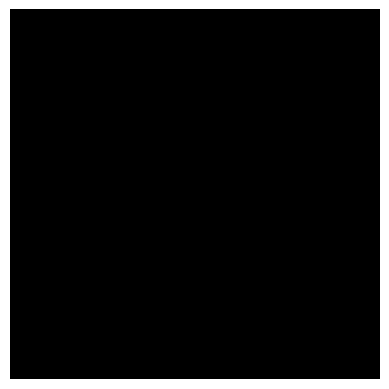

Data type of the image: uint8


In [4]:
#Your solution
display100=np.zeros((100,100), dtype=np.uint8)
plt.imshow(display100, cmap='gray')
plt.axis('off') # turn off axis labels
plt.show()
print("Data type of the image:", display100.dtype)

**b) How many distinct intensity levels can each pixel represent in this uint8 grayscale image? Explain your answer.**

In [5]:
# Your solution (number of distinct intensity levels)
256

# Your explanation
#El datatype de unit8 permet que cada pixel de la imatge tingui un valor entre 0 i 255, per tant hi han 256 nivells ditintius per a cada pixel.

256

**c) Create and display a 100 × 100 RGB image represented as a 3D array.**
 - Each element of the array must be an 8-bit unsigned integer (`uint8`). 
 - Initialize all elements to zero. 
 - Then, convert the RGB image to Grayscale using `rgb2gray`.
 - Print the data type (dtype) and dimension (shape) of both images.

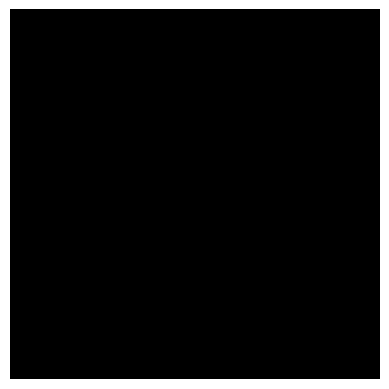

Data type of the image: float64


In [6]:
#Your solution
from skimage.color import rgb2gray
displayRGB=np.zeros((100,100,3), dtype=np.uint8)
displayRGBgrey = rgb2gray(displayRGB)
plt.imshow(displayRGBgrey, cmap='gray')
plt.axis('off') # turn off axis labels
plt.show()
print("Data type of the image:", displayRGBgrey.dtype)

**d) Modify the pixel values of the image created in Section 1.1(a) to reproduce the images shown below. Display the modified images using a figure with three subplots.**

![./images_notebook/gray_grid.png](./images_notebook/gray_grid.png)

Visualize the images and print the values of its first row.

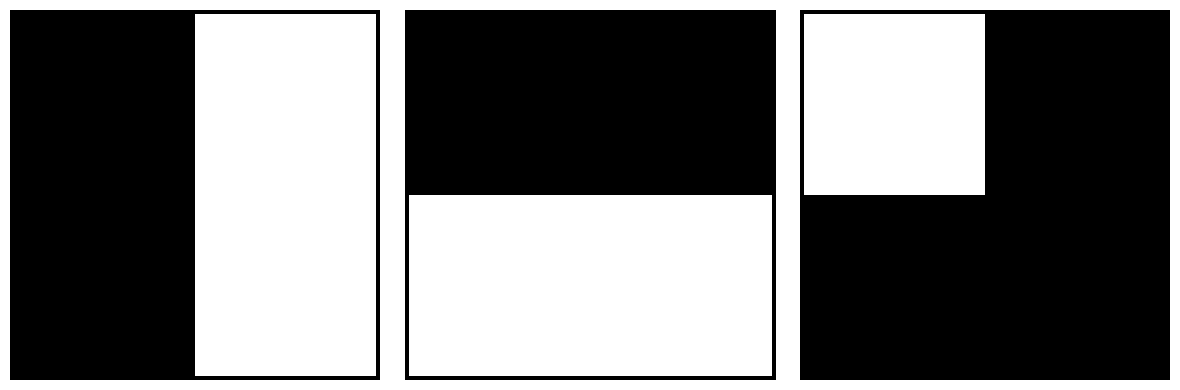

In [7]:
#Your solution
img1 = display100.copy()
img1[1:99, 50:99] = 255 #Deixem un pixel per marcar el limit de la figura

img2 = display100.copy()
img2[50:99, 1:99] = 255

img3 = display100.copy()
img3[1:50, 1:50] = 255

fig = plt.figure(figsize=(12,4))

fig.add_subplot(1, 3, 1)

plt.imshow(img1, cmap='gray')
plt.axis('off') # turn off axis labels

fig.add_subplot(1, 3, 2)
plt.imshow(img2, cmap='gray')
plt.axis('off') # turn off axis labels

fig.add_subplot(1, 3, 3)
plt.imshow(img3, cmap='gray')
plt.axis('off') # turn off axis labels

plt.tight_layout()

plt.show()

**e) Vertically flip the third image, generated above, to create a mirror illusion, as illustrated below.**
- Display the resulting image while preserving the axes. 
- You can consult the NumPy documentation for help: [NumPy `flip` documentation](https://numpy.org/devdocs/reference/generated/numpy.flip.html).


![./images_notebook/mirror.png](./images_notebook/mirror.png)

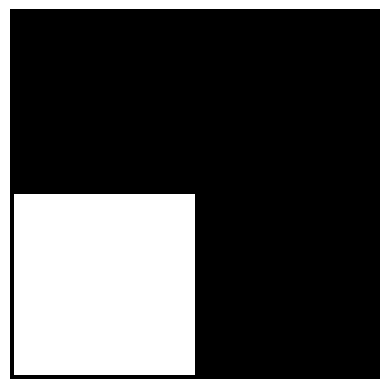

In [8]:
#Your solution
img4 = img3.copy()
img4 = np.flipud(img4)

plt.imshow(img4, cmap='gray')
plt.axis('off') # turn off axis labels
plt.show()



**f) Create an RGB image by combining the three grayscale images created in the previous steps.**

Follow these steps:

1. Create a **100 × 100 RGB image** using the `uint8` data type and initialize all pixel values to zero.
2. Use the first grayscale image (`img1`) to define the **red channel** of the RGB image.
3. Use the second grayscale image (`img2`) to define the **green channel**.
4. Use the third grayscale image (`img3`) to define the **blue channel**.
5. Display the resulting RGB image (the expected result is illustrated below).
 
![./images_notebook/color_grid.png](./images_notebook/color_grid.png)

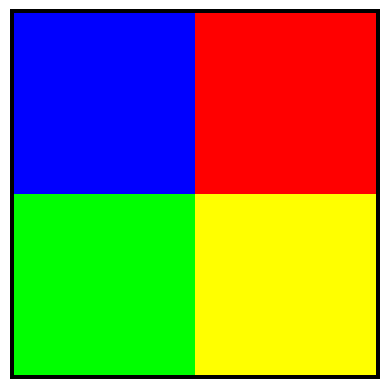

In [9]:
#Your solution
img5 = np.zeros((100,100,3), dtype=np.uint8)
img5[img1==255] = img5[img1==255] + [255, 0, 0] #Red
img5[img2==255] = img5[img2==255] + [0, 255, 0] #Green
img5[img3==255] = img5[img3==255] + [0, 0, 255] #Blue

plt.imshow(img5)
plt.axis('off') # turn off axis labels
plt.show()

### **1.2 Image saving and loading**

**a) Use the `io` module to save the previously generated RGB image in a directory named `output`.**
- If the directory does not exist, we create it using Python.
- Save the image with the filename `rgb_image.png`.


In [10]:
import os
if not os.path.exists("output"):
    os.mkdir("output")

In [11]:
#Your solution
io.imsave("output/rgb_image.png", img5)

**b) Load the saved image and display it.**
- Additionally, print its dimensions, the value of the pixel at `(10, 10)`, and its data type (`dtype`) to verify that everything is correct.

(100, 100, 3)
uint8
[  0   0 255]


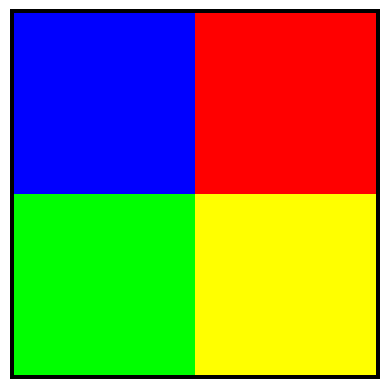

In [12]:
#Your solution
img6 = io.imread("output/rgb_image.png")

print(img6.shape)
print(img6.dtype)
print(img6[10, 10, :])

plt.imshow(img6)
plt.axis('off') # turn off axis labels
plt.show()

### **1.3 Basic image manipulations: RGB to grayscale, data type conversion, thresholding, and more**

**a) Load and display the image `panda.jpg` from the `images_notebook` directory.**
 - Print the image dimensions and data type. 
 - Then, convert it to grayscale using `rgb2gray`. 
 - Display the resulting grayscale image using an appropriate colormap.
 - Print the image dimensions and data type of the grayscale image. 


(800, 1200, 3)
uint8


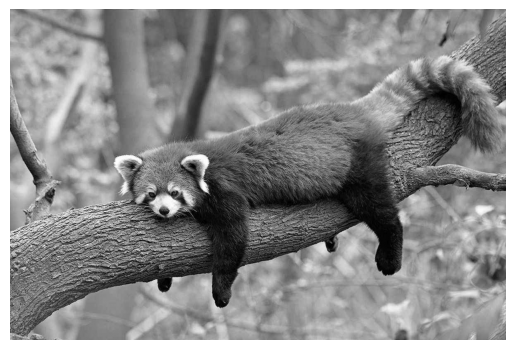

In [13]:
#Your solution
img7 = io.imread("images_notebook/panda.jpg")

print(img7.shape)
print(img7.dtype)

img8 = rgb2gray(img7)

plt.imshow(img8, cmap='gray')
plt.axis('off')
plt.show()

**b) Save the grayscale image**

- Save the grayscale image generated above in the `output` directory with the filename `panda_gray.jpg`.
- Check the [documentation](https://scikit-image.org/docs/stable/api/skimage.util.html#skimage.util.img_as_ubyte) for `img_as_ubyte` to understand how to convert the grayscale image to `uint8` before saving it.
- Display the original RGB image and the grayscale image side by side in a figure with two subplots.
- Print the minimum and maximum values of each image:
  - RGB
  - Grayscale (original)
  - Grayscale (after converting it to uint8)

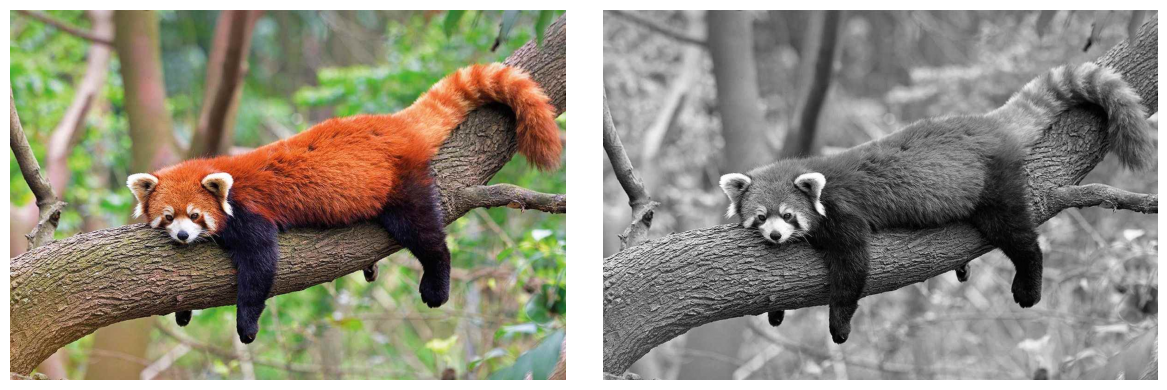

RGB: 0 255
Gray: 0.0 1.0
Gray (uint8): 0 255


In [14]:
# Your solution
import skimage
img9 = skimage.util.img_as_ubyte(img8)
io.imsave("output/panda_gray.png", img9)

fig = plt.figure(figsize=(12,4))
fig.add_subplot(1, 2, 1)
plt.imshow(img7, cmap='gray')
plt.axis('off') # turn off axis labels
fig.add_subplot(1, 2, 2)
plt.imshow(img8, cmap='gray')
plt.axis('off') # turn off axis labels

plt.tight_layout()
plt.show()

print("RGB:", img7.min(), img7.max())
print("Gray:", img8.min(), img8.max())
print("Gray (uint8):", img9.min(), img9.max())


**c) Compute the mean of the previous grayscale image (before converting it to `uint8`) and use a logical operation to obtain a binary image.** 
- Pixels with values greater than the mean should be displayed as white (`1`), while all other pixels should be displayed as black (`0`). 
- Display the resulting binary image.


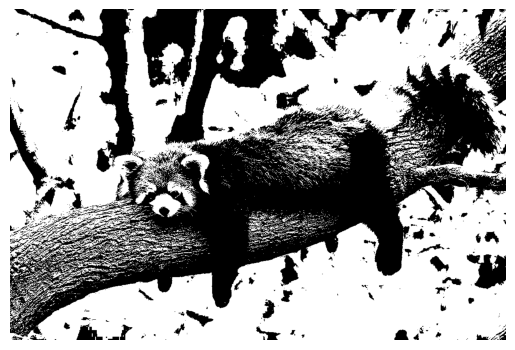

In [15]:
# Your solution
mean = np.mean(img8)
img10 = img8.copy()
img10[img10 < mean] = 0
img10[img10 >= mean] = 1
plt.imshow(img10, cmap='gray')
plt.axis('off') # turn off axis labels
plt.show()

**d) Display the original RGB image, the grayscale image, and the binary image side by side in a figure with three subplots.**
- Add the titles `Original`, `Grayscale`, and `Binary`, respectively, and hide the axes.

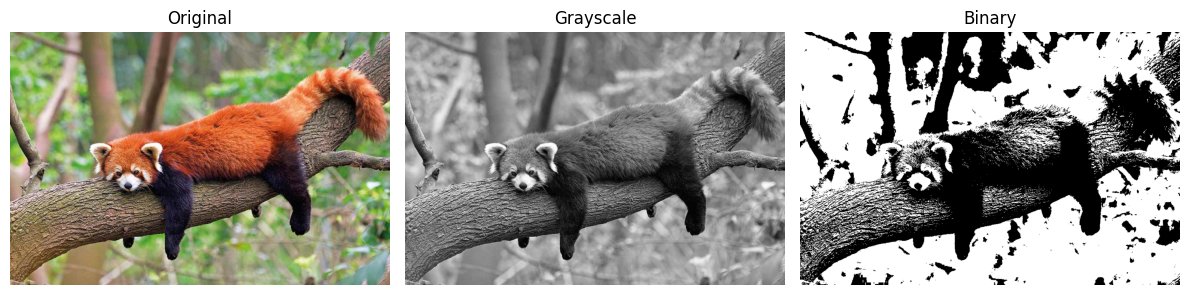

In [16]:
# Your solution
fig = plt.figure(figsize=(12,4))

fig.add_subplot(1, 3, 1)
plt.imshow(img7)
plt.axis('off') # turn off axis labels
plt.title("Original")
fig.add_subplot(1, 3, 2)
plt.imshow(img8, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Grayscale")
fig.add_subplot(1, 3, 3)
plt.imshow(img10, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Binary")
plt.tight_layout()
plt.show()

**e) Create a new RGB black image that is 15% larger than the original `panda` image in both height and width. Then, embed the original panda image in the center of the new image.**

Follow these steps:

1. Use the previously loaded image `img_panda`.
2. Retrieve the **shape** of `img_panda` to determine its height, width, and number of channels.
3. Create a new black RGB image whose:
   - height is 15% larger than the height of `img_panda`;
   - width is 15% larger than the width of `img_panda`;
   - number of channels is 3.
4. Use the `uint8` data type for the new image.
5. Place `img_panda` in the **center** of the new black image using array slicing.
6. Display the resulting framed image (expected result is shown below).

> **Note:** Be careful with the **number of channels** when creating the new image. An RGB image must have three channels.

> **Note:** Print the shapes of both `img_panda` and the new image. Verify that the height and width of the new image are approximately **15% larger** than those of the original image.

> **Optional:** As an alternative approach, investigate how the `rescale` function from `skimage.transform` could be used to create an image 15% larger.

![./images_notebook/gray_grid.png](./images_notebook/framed_panda.jpg)

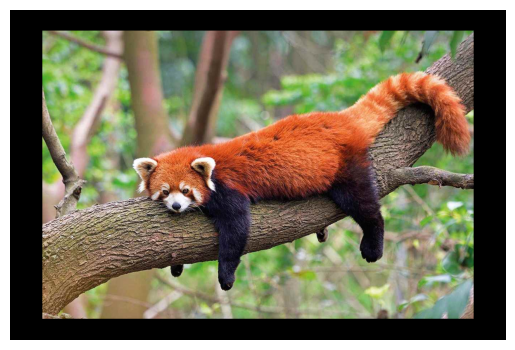

In [17]:
# Your solution
img11 = np.zeros(((int)(img7.shape[0]*1.15),(int)(img7.shape[1]*1.15) , 3), dtype=np.uint8)
img11[(int)(img7.shape[0]*0.075):(int)(-img7.shape[0]*0.075+1), (int)(img7.shape[1]*0.075):(int)(-img7.shape[1]*0.075), :] = img7

plt.imshow(img11)
plt.axis("off")
plt.show()


**f) Change the frame of the new image to green.** 
- Display the three images (the original image, the image with a black frame, and the image with a green frame) in a single figure, with their respective titles.
- Expected result is illustrated below.

![./images_notebook/gray_grid.png](./images_notebook/framed_panda_green.jpg)

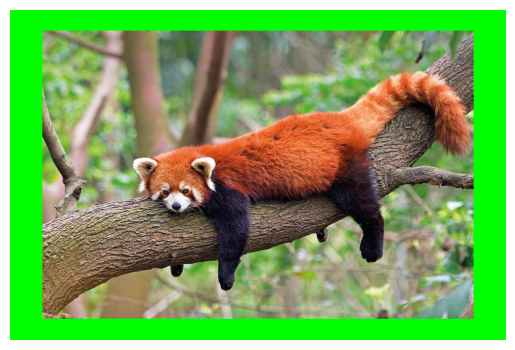

In [18]:
# Your solution
img12 = img11.copy()

mask = np.all(img12 == [0, 0, 0], axis=-1)

img12[mask] = [0, 255, 0]

plt.imshow(img12)
plt.axis("off")
plt.show()

### **1.4 Brightness Adjustment**

In some application domains, such as medical imaging, images may exhibit low contrast, making it difficult to distinguish structures and details.

**a) Load the image `images_notebook/cell_lowcontrast2.png` and display it without applying any contrast enhancement.** 

Then:

1. Print the **shape** of the image.
2. Print its **data type**.
3. Print the **minimum** and **maximum** pixel values.

> **Note:** When displaying an image with `imshow()`, Matplotlib automatically adjusts the displayed intensity range to enhance the image contrast. As a result, the image may appear to have better contrast than it actually does. To visualize the image using its original intensity values, specify the `vmin` and `vmax` parameters in `imshow()`. Choose appropriate values according to the image data type. For example, for an 8-bit unsigned integer (`uint8`) image, the full intensity range is from `0` to `255`.

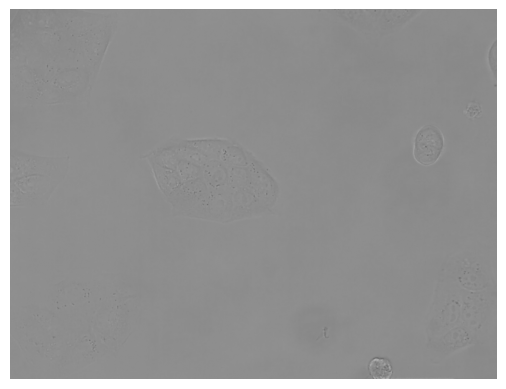

Shape:  (898, 1181) 
Datatype:  uint8 
Min:  80  Max:  181


In [19]:
# Your solution
img13 = io.imread("images_notebook/cell_lowcontrast2.png")
plt.imshow(img13, vmax=255, vmin=0, cmap='gray')
plt.axis("off")
plt.show()
print("Shape: ", img13.shape, "\nDatatype: ", img13.dtype, "\nMin: ", img13.min(), " Max: ", img13.max())

**b) Create a new image called `dark_image` by modifying the pixel values of the original image.**

Follow these steps:

1. Compute the **minimum pixel value** of the original image.
2. Create `dark_image` by subtracting this minimum value from every pixel in the original image.
3. Print the **minimum** and **maximum** pixel values of `dark_image`.
4. Pring the **shape** and *dtype** of the generated image.
5. Display `dark_image` **without applying any automatic contrast enhancement**.

> **Note:** Use the same `vmin` and `vmax` values as in the previous exercise so that the displayed image reflects the actual pixel intensities and is not automatically enhanced by `imshow()`.

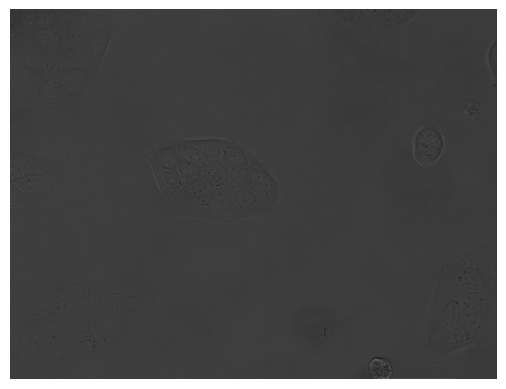

min & Max:  0 101 
Shape:  (898, 1181) 
Dtype:  uint8


In [20]:
# Your solution
img13_min = img13.min()
img13_max = img13.max()
dark_image = img13.copy() - img13_min
plt.imshow(dark_image, vmax=255, vmin=0, cmap='gray')
plt.axis("off")
plt.show()
print("min & Max: ", dark_image.min(), dark_image.max(), "\nShape: ", dark_image.shape, "\nDtype: ", dark_image.dtype)

**c) Similarly to the previous question, create a new image called `bright_im` by modifying the pixel values of the original image so that the maximum pixel value becomes 255**.

Follow these steps:

1. Compute the **maximum pixel value** of the original image.
2. Determine the value that must be added to each pixel so that the maximum intensity in the new image is `255`.
3. Create `bright_im` by adding this value to all pixels in the original image.
4. Print the **minimum** and **maximum** pixel values of `bright_im`.
5. Pring the **shape** and *dtype** of the generated image.
6. Display `bright_im` **without applying any automatic contrast enhancement**.

> **Note:** Use the same `vmin` and `vmax` values as in the previous exercises so that the image is displayed using its actual intensity values.

min & Max:  154 255 
Shape:  (898, 1181) 
Dtype:  uint8


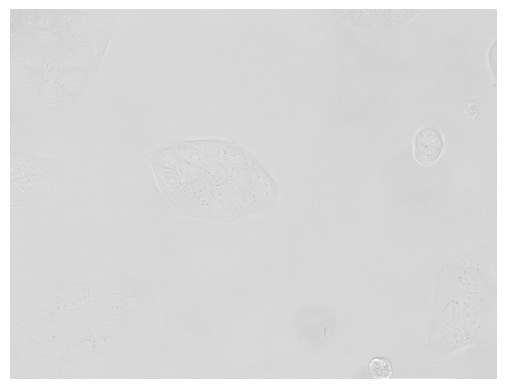

In [21]:
# Your solution
bright_diff = 255- img13_max
bright_im = img13.copy() + bright_diff

print("min & Max: ", bright_im.min(), bright_im.max(), "\nShape: ", bright_im.shape, "\nDtype: ", bright_im.dtype)
plt.imshow(bright_im, vmax=255, vmin=0, cmap='gray')
plt.axis("off")
plt.show()

**d) Display the original image, `dark_image`, and `bright_im` side by side in a single figure with three subplots.**
- Use the same `vmin` and `vmax` values for all three images to avoid automatic contrast enhancement.


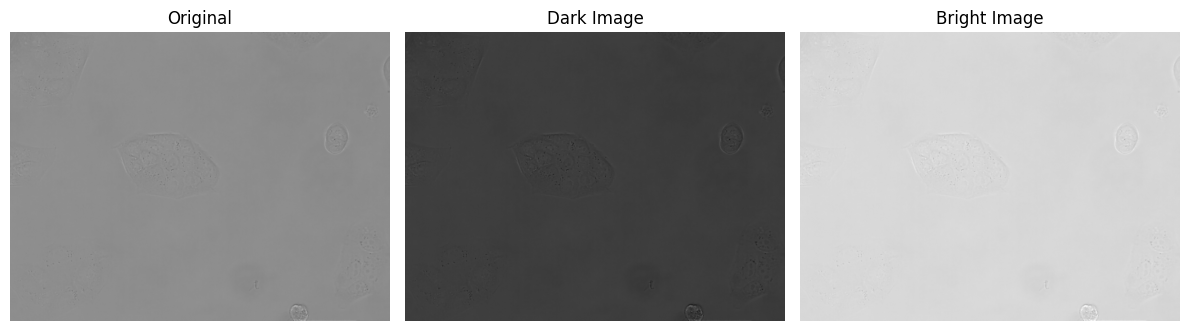

In [22]:
# Your solution
fig = plt.figure(figsize=(12,4))

fig.add_subplot(1, 3, 1)
plt.imshow(img13, vmax=255, vmin=0, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Original")
fig.add_subplot(1, 3, 2)
plt.imshow(dark_image, vmax=255, vmin=0, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Dark Image")
fig.add_subplot(1, 3, 3)
plt.imshow(bright_im, vmax=255, vmin=0, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Bright Image")
plt.tight_layout()
plt.show()

**e) Contrast Stretching: create a new image by rescaling the pixel intensity values of the original image to the range [0, 1] using the following two approaches:**

- **Option 1 — Mathematical formula:** Perform the intensity rescaling manually using the contrast-stretching formula.
- **Option 2 — `rescale_intensity`:** Use the [`rescale_intensity`](https://scikit-image.org/docs/stable/api/skimage.exposure.html#skimage.exposure.rescale_intensity) function from `skimage.exposure` to perform the same operation.


**Option 1 — Using the mathematical formula**

1. Compute the **minimum** and **maximum** pixel values of the original image.

2. Rescale the pixel values to the range **[0, 1]** using the following formula:

   $
   \Large
   \qquad I_{\text{normalized}} =
   \frac{I - I_{\min}}{I_{\max} - I_{\min}}
   $

3. Print the **minimum** and **maximum** values of the resulting image to verify that they are `0` and `1`.

**Option 2 — Using `rescale_intensity`**

4. Use the [`rescale_intensity`](https://scikit-image.org/docs/stable/api/skimage.exposure.html#skimage.exposure.rescale_intensity) function from `skimage.exposure` to perform the same intensity rescaling.

5. Print the **minimum** and **maximum** values of the resulting image.

**Comparison**

6. Display the following images side by side in a **1×3 grid**:

   - the **original image**;
   - the image obtained using the **mathematical formula**;
   - the image obtained using **`rescale_intensity`**.

7. Use the appropriate intensity range (`vmin` and `vmax`) when displaying each image.

> **Tip:** Check the intensity range of each image before choosing `vmin` and `vmax`. Images with pixel values in the range **[0, 1]** should be displayed using `vmin=0` and `vmax=1`, while images with `uint8` pixel values in the range **[0, 255]** should be displayed using `vmin=0` and `vmax=255`.

8. Add the titles **Original**, **Formula**, and **Rescale intensity** to the corresponding subplots and hide the axes.

Formula: max & min:  1.0 0.0


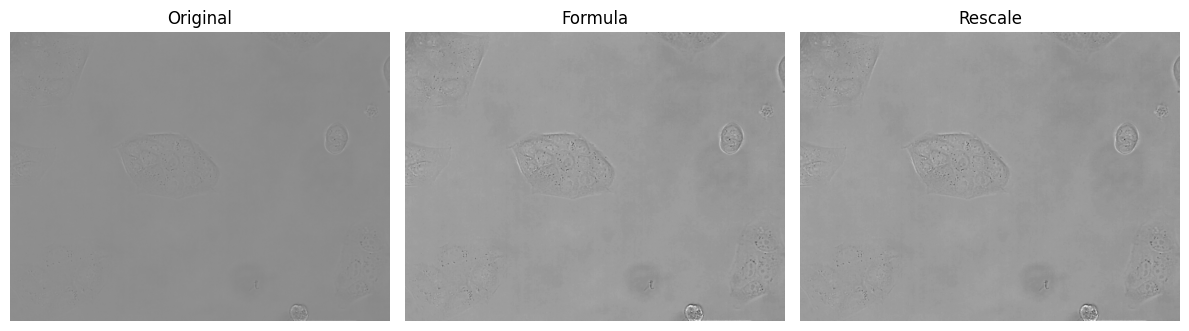

In [23]:
# Your solution
import skimage
formula = (img13.copy()-img13_min)/(img13_max-img13_min)
print("Formula: max & min: ", formula.max(), formula.min())

rescale = skimage.exposure.rescale_intensity(img13.copy())

fig = plt.figure(figsize=(12,4))
fig.add_subplot(1, 3, 1)
plt.imshow(img13, vmax=255, vmin=0, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Original")
fig.add_subplot(1, 3, 2)
plt.imshow(formula, vmax=1, vmin=0, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Formula")
fig.add_subplot(1, 3, 3)
plt.imshow(rescale, vmax=255, vmin=0, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Rescale")
plt.tight_layout()
plt.show()

**f) Display the five images in a single figure, using one subplot for each image.** 
- Add the corresponding titles: *Original*, *Dark Image*, *Bright Image*, *Formula*, and *Rescale intensity*.


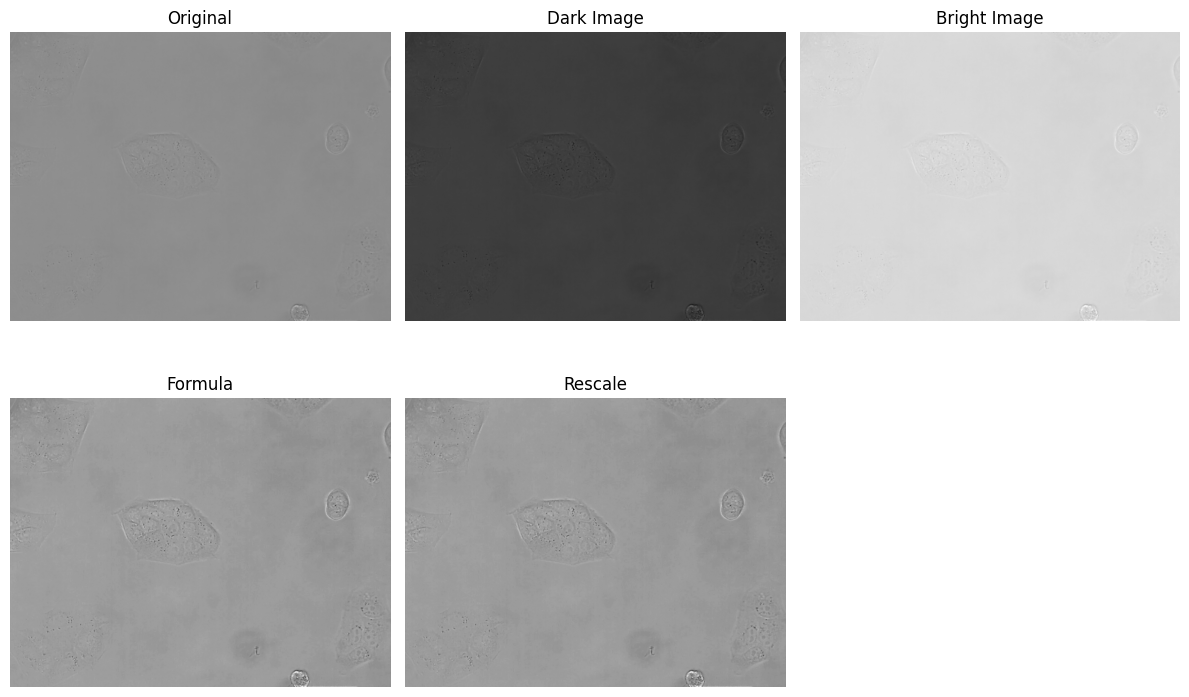

In [24]:
# Your solution
fig = plt.figure(figsize=(12,8))
fig.add_subplot(2, 3, 1)
plt.imshow(img13, vmax=255, vmin=0, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Original")
fig.add_subplot(2,3,2)
plt.imshow(dark_image, vmax=255, vmin=0, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Dark Image")
fig.add_subplot(2, 3, 3)
plt.imshow(bright_im, vmax=255, vmin=0, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Bright Image")
plt.tight_layout()
fig.add_subplot(2, 3, 4)
plt.imshow(formula, vmax=1, vmin=0, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Formula")
fig.add_subplot(2, 3, 5)
plt.imshow(rescale, vmax=255, vmin=0, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Rescale")
plt.tight_layout()
plt.show()

### **1.5 Color manipulation**

**a) Load the image `images_notebook/barcelona.jpg` (shown below). Extract the three color channels (red, green, and blue) and display them in a single figure, using one subplot for each channel and adding the corresponding titles: *Red channel*, *Green channel*, and *Blue channel* (bottom figure).**

<img src="images_notebook/barcelona.jpg">

<img src="images_notebook/barcelona_channels.png">

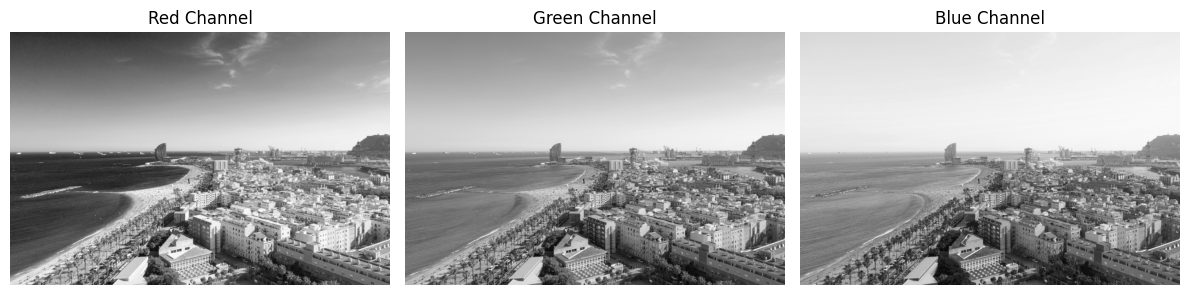

In [25]:
# Your solution
img14 = io.imread("images_notebook/barcelona.jpg")
img14_R=img14[:,:,0]
img14_G=img14[:,:,1]
img14_B=img14[:,:,2]
fig = plt.figure(figsize=(12,4))
fig.add_subplot(1, 3, 1)
plt.imshow(img14_R, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Red Channel")
fig.add_subplot(1, 3, 2)
plt.imshow(img14_G, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Green Channel")
fig.add_subplot(1, 3, 3)
plt.imshow(img14_B, cmap='gray')
plt.axis('off') # turn off axis labels
plt.title("Blue Channel")
plt.tight_layout()
plt.show()

**b) Channel Interchange:** Load the image `images_notebook/chairs.jpg`, interchange its red and blue channels, and display the original and resulting images side by side in a figure with two subplots, titled **Original** and **Red and Blue Channels Interchanged**, respectively.



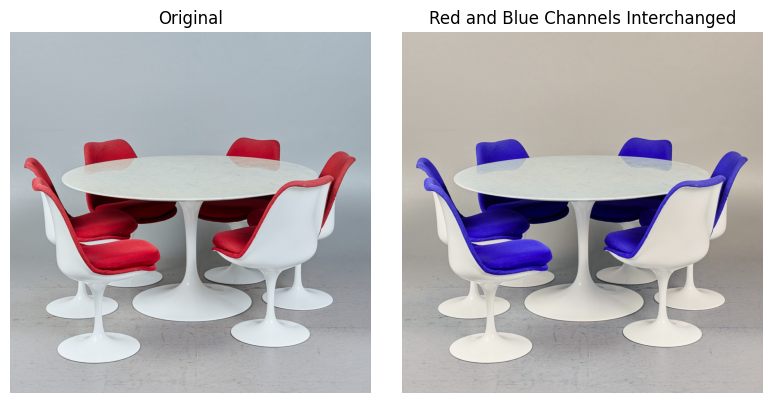

In [53]:
# Your solution
img15=io.imread("images_notebook/chairs.jpg")
img15[:,:,[0,2]] = img15[:,:,[2,0]]
fig = plt.figure(figsize=(8,4))
fig.add_subplot(1, 2, 1)
plt.imshow(io.imread("images_notebook/chairs.jpg"))
plt.axis('off') 
plt.title("Original")
fig.add_subplot(1, 2, 2)
plt.imshow(img15)
plt.axis('off') 
plt.title("Red and Blue Channels Interchanged")
plt.tight_layout()
plt.show()

### **1.6 Masks and logical image manipulation**

**a) Load the image `images_notebook/circles.bmp` and create three new images, each containing only one of the circles from the original image (as illustrated below).**
- The three circles are located in the following column ranges: **0–299** (left circle), **300–599** (center circle), and **600–the last column of the image** (right circle). 
- Copy and paste each circle from the original image into the corresponding new image, preserving its original position without shifting it. 
- Display the original image and the three resulting images in a single figure, with one subplot for each image and the corresponding title.

<img src="images_notebook/circles2.png">

> **Note:** Be careful when using `imshow()`, as it may automatically adjust the displayed intensity range, making the image appear to have higher contrast than it actually does. Also, take care when converting the image data type. Always check the **data type** and **range of pixel values** before and after the conversion.
he contrast of the image. Also be careful when applying type conversion. Check the ranges of the image values.

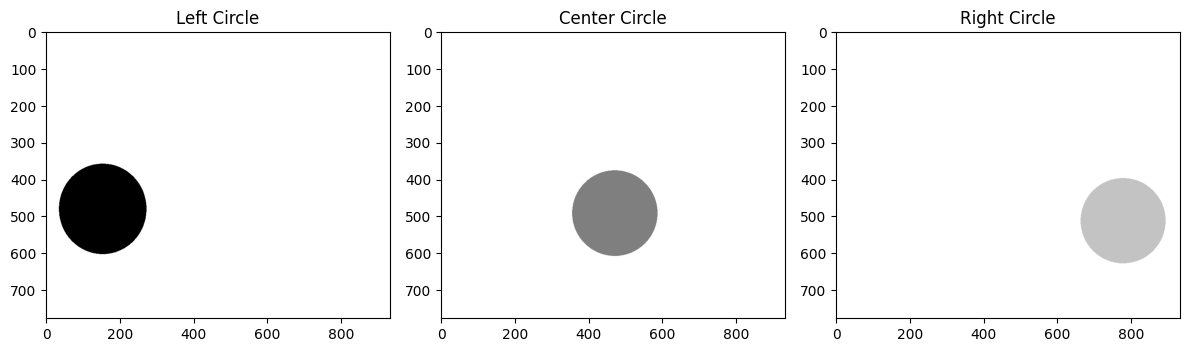

In [ ]:
#Your solution
img16 = io.imread("images_notebook/circles.bmp")
img16_L = img16.copy()
img16_L[:,300:] = 255
img16_C = img16.copy()
img16_C[:,:301] = 255
img16_C[:,600:] = 255
img16_R = img16.copy()
img16_R[:,:601] = 255
fig = plt.figure(figsize=(12,4))
fig.add_subplot(1, 3, 1)
plt.imshow(img16_L, cmap='gray')
plt.title("Left Circle")
fig.add_subplot(1, 3, 2)
plt.imshow(img16_C, cmap='gray')
plt.title("Center Circle")
fig.add_subplot(1, 3, 3)
plt.imshow(img16_R, cmap='gray')
plt.title("Right Circle")
plt.tight_layout()
plt.show()

**b) Create three new images, each containing two of the three circles from the original image while preserving their original positions.**

* The first image must contain the **center and right circles**.
* The second image must contain the **left and right circles**.
* The third image must contain the **left and center circles**.
* Display the three resulting images in a single figure, with one subplot for each image and the corresponding title, as illustrated below.

<img src="images_notebook/circles3.png">



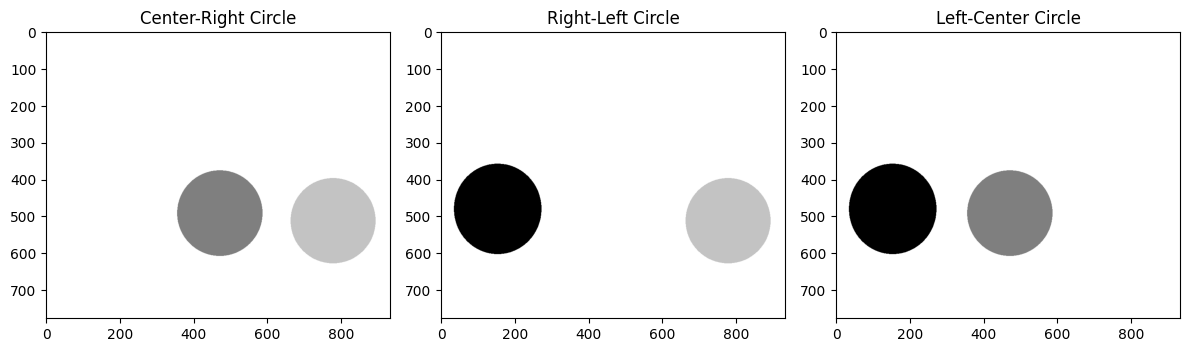

In [59]:
# Your solution
img16_CR = img16.copy()
img16_CR[:,:300] = 255
img16_RL = img16.copy()
img16_RL[:,301:600] = 255
img16_LC = img16.copy()
img16_LC[:,601:] = 255
plt.figure(figsize=(12,4))
plt.subplot(1, 3, 1)
plt.imshow(img16_CR, cmap='gray')
plt.title("Center-Right Circle")
plt.subplot(1, 3, 2)
plt.imshow(img16_RL, cmap='gray')
plt.title("Right-Left Circle")
plt.subplot(1, 3, 3)
plt.imshow(img16_LC, cmap='gray')
plt.title("Left-Center Circle")
plt.tight_layout()
plt.show()

**c) Load the RGBA image `images_notebook/coat.png` and change the color of the coat by interchanging its red and blue channels, as illustrated below.**

Follow these steps:

1. Load the image and identify the pixels that are **not black**, considering only the RGB channels.
2. Create a copy of the original image.
3. For the selected pixels, interchange the **red and blue channels** while keeping the green and alpha channels unchanged.
4. Display the original and modified images side by side in a figure with two subplots, titled Original and Red and Blue Channels Interchanged, respectively.

> **Note:** Remember that the image has **four channels**: red, green, blue, and alpha (RGBA). When manipulating the color channels, make sure that the **alpha channel remains unchanged**.

> **Important:** Do **not** use a `for` loop to process the pixels individually. Use **NumPy array operations and Boolean masking** to perform the manipulation efficiently.

<img src="images_notebook/coat_changed.png"  width="500">

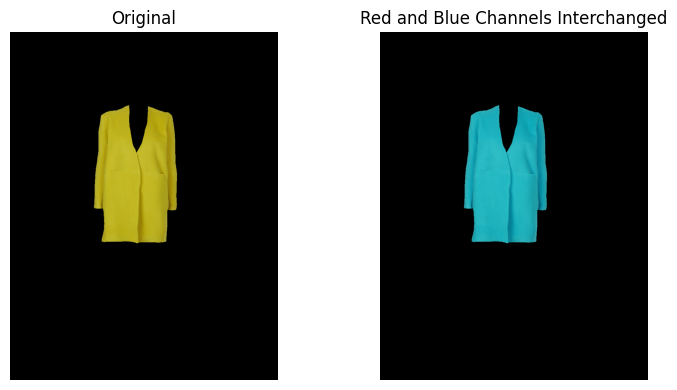

In [63]:
# Load the RGBA image
img17 = io.imread("images_notebook/coat.png")
img17_c = img17.copy()
img17_c[:,:,[0,2]] = img17_c[:,:,[2,0]]
fig = plt.figure(figsize=(8,4))
fig.add_subplot(1, 2, 1)
plt.imshow(img17)
plt.axis('off')
plt.title("Original")
fig.add_subplot(1, 2, 2)
plt.imshow(img17_c)
plt.axis('off')
plt.title("Red and Blue Channels Interchanged")
plt.tight_layout()
plt.show()

**d) Overlay the Coat on the Model**

Use the images `images_notebook/model.png`, `images_notebook/coat.png`, and the color-changed coat generated above to overlay the coat onto the model, as illustrated below.

Follow these steps:

1. Load the **model** and **coat** images.

2. Create a mask to identify the **non-black pixels** of the coat, considering only the RGB channels.

3. Create a copy of the model image and overlay the **original coat** onto it using the mask.

4. Create another copy of the model image and overlay the **color-changed coat** (`img_coat_changed`) onto it using the same mask.

5. Display the following four images side by side in a **1×4 grid**:

   * **Coat**
   * **Model**
   * **Model with coat**
   * **Model with changed coat**

6. Hide the axes and add the corresponding titles to each subplot.

> **Note:** Both images have **four channels (RGBA)**. When overlaying the coat, modify only the **RGB channels** (`:3`) and leave the **alpha channel** unchanged.

> **Important:** Do **not** use a `for` loop to process the pixels individually. Use **NumPy array operations and Boolean masking** instead.

<img src="images_notebook/model_changed.png"  width="900">

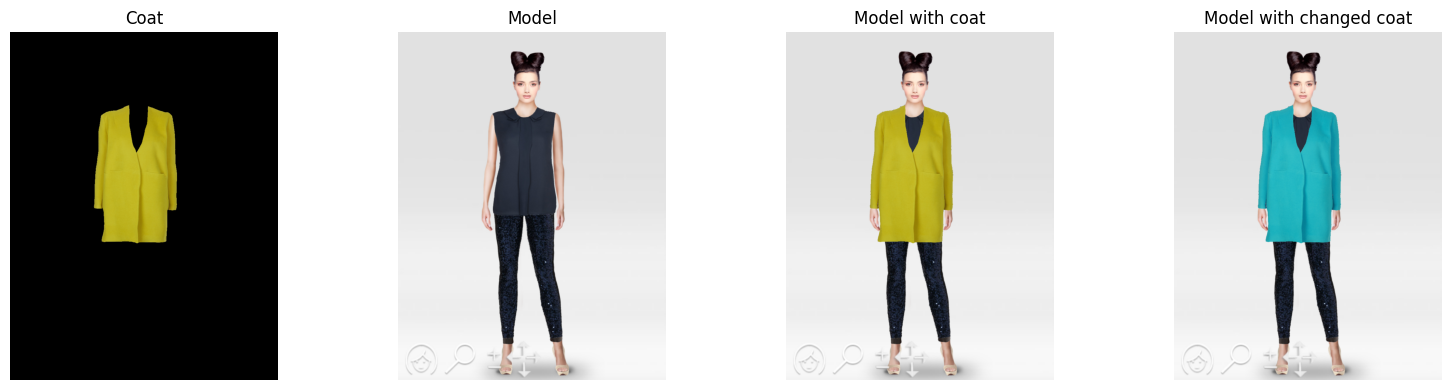

In [66]:
# Your solution
img18 = io.imread("images_notebook/model.png")
img18_O = img18.copy()
img18_O = np.where(img17[:,:,:] > 0, img17, img18_O)
img18_C = np.where(img17_c[:,:,:] > 0, img17_c, img18)
fig = plt.figure(figsize=(16,4))
fig.add_subplot(1, 4, 1)
plt.imshow(img17)
plt.axis('off')
plt.title("Coat")
fig.add_subplot(1, 4, 2)
plt.imshow(img18)
plt.axis('off')
plt.title("Model")
fig.add_subplot(1, 4, 3)
plt.imshow(img18_O)
plt.axis('off')
plt.title("Model with coat")
fig.add_subplot(1, 4, 4)
plt.imshow(img18_C)
plt.axis('off')
plt.title("Model with changed coat")
plt.tight_layout()
plt.show()